In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [48]:
from pathlib import Path

In [49]:
print(Path.cwd())

C:\Users\chira\OneDrive\Desktop\customer-churn-predictor\notebooks


In [50]:
from pathlib import Path

project = Path.cwd()

print("Current folder:", project)
print("\nFiles/folders here:")
for item in project.iterdir():
    print(item.name)

Current folder: C:\Users\chira\OneDrive\Desktop\customer-churn-predictor\notebooks

Files/folders here:
.ipynb_checkpoints
01_data_understanding.ipynb
test_environment.ipynb


#### Understanding data

In [51]:
project_root = Path.cwd().parent
data_path = project_root / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(data_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
df.shape

(7043, 21)

In [53]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [55]:
df.drop(columns=["customerID"],inplace=True)

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [57]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(22)

In [59]:
df["TotalCharges"] = df["TotalCharges"].replace({" " : "0.0"})

In [60]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [61]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [62]:
df[["TotalCharges","MonthlyCharges","tenure"]].corr()

,TotalCharges,MonthlyCharges,tenure
TotalCharges,1.000000,0.651174,0.826178
MonthlyCharges,0.651174,1.000000,0.247900
tenure,0.826178,0.247900,1.000000


<Axes: >

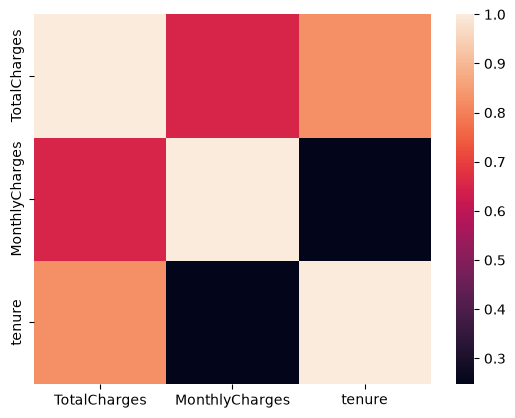

In [63]:
sns.heatmap(df[["TotalCharges","MonthlyCharges","tenure"]].corr())

#### EDA

#### numerical feature analysis

In [64]:
num_cols = df.select_dtypes(include="number").columns

In [65]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [66]:
def hist_plot(df, column):
    plt.figure(figsize=(6,6))
    sns.histplot(df,x=column,kde=True)
    plt.title(f"Distribution of : {column}")
    plt.xlabel(f"{column}")
    plt.ylabel(f"Number of customer")
    plt.show()

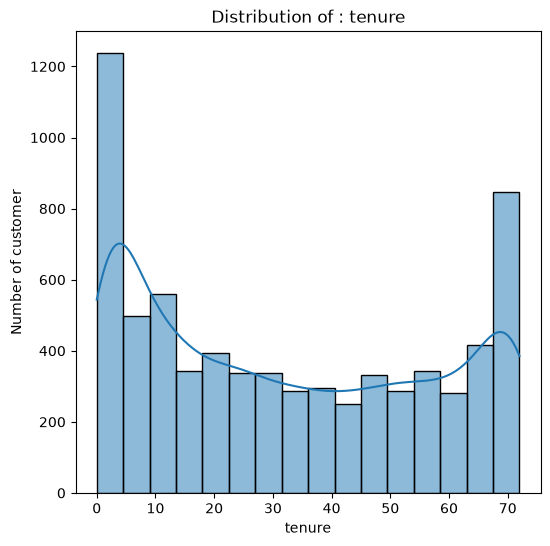

In [67]:
hist_plot(df, 'tenure')

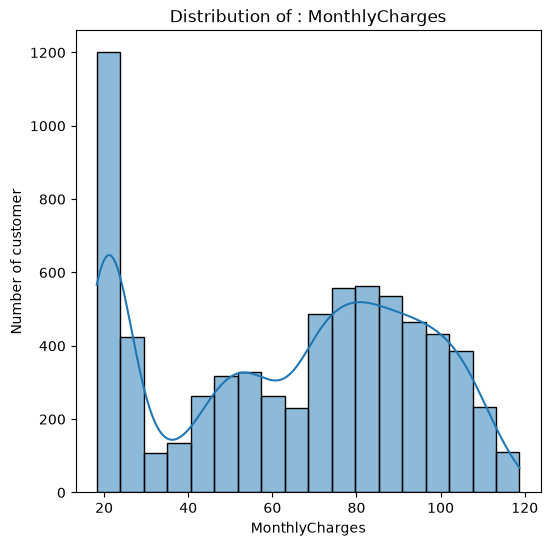

In [68]:
hist_plot(df, 'MonthlyCharges')

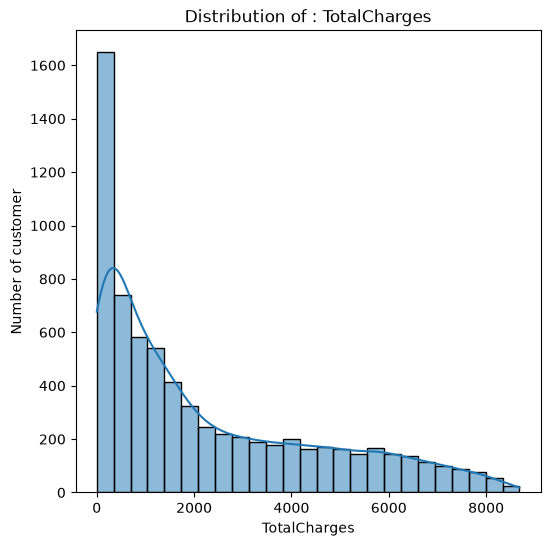

In [69]:
hist_plot(df, "TotalCharges")

In [70]:
def box_plot(df, x_column, churn="Churn"):
    plt.figure(figsize=(5,5))
    sns.boxplot(x=df[x_column] ,hue=df[churn])
    plt.title("box-plot")
    plt.xlabel(f"{x_column}")
    plt.show()

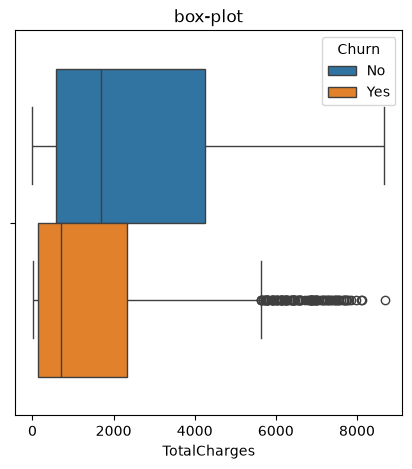

In [71]:
box_plot(df,"TotalCharges")

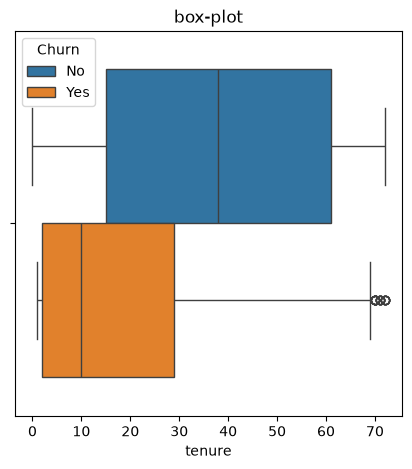

In [72]:
box_plot(df,"tenure")

<Axes: xlabel='tenure', ylabel='TotalCharges'>

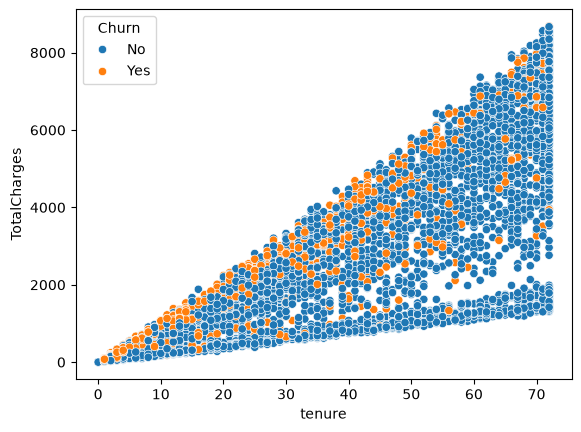

In [73]:
sns.scatterplot(df,x="tenure",y="TotalCharges",hue="Churn")

In [74]:
np.sort(df["MonthlyCharges"].unique())

array([ 18.25,  18.4 ,  18.55, ..., 118.6 , 118.65, 118.75], shape=(1585,))

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

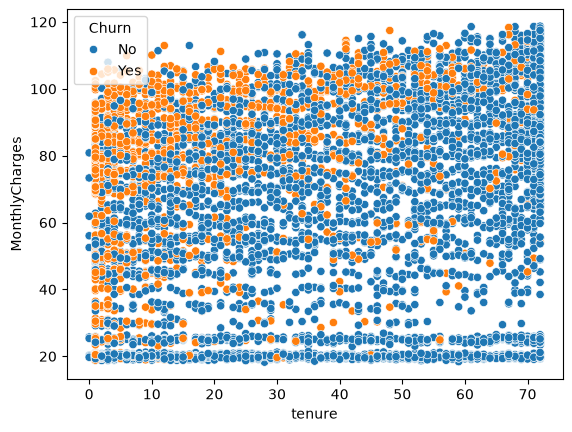

In [75]:
sns.scatterplot(df,x="tenure",y="MonthlyCharges",hue="Churn")

In [76]:
def line_plot(df, x_column, y_column):
    plt.figure(figsize=(6,6))
    sns.lineplot(df,x=x_column,y=y_column)
    plt.title(f"Relation of : {x_column} vs {y_column}")
    plt.xlabel(f"{x_column}")
    plt.ylabel(f"{y_column}")
    plt.show()

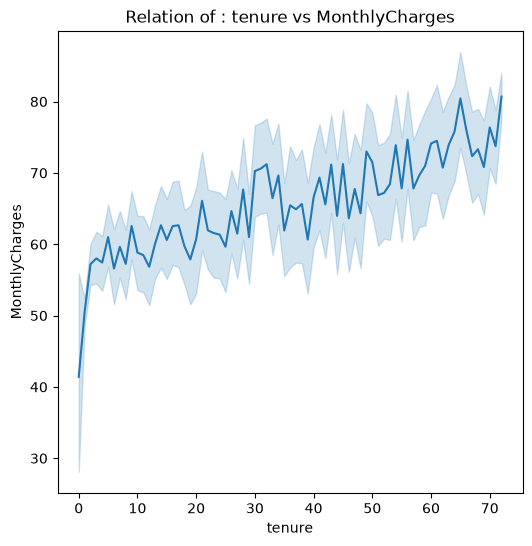

In [77]:
line_plot(df, "tenure", "MonthlyCharges")

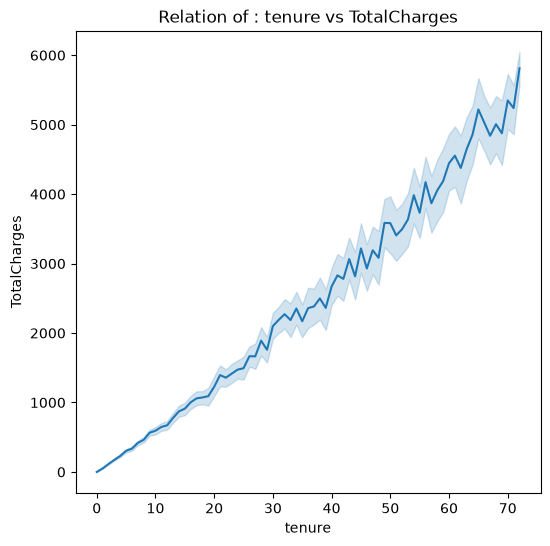

In [78]:
line_plot(df, "tenure", "TotalCharges")

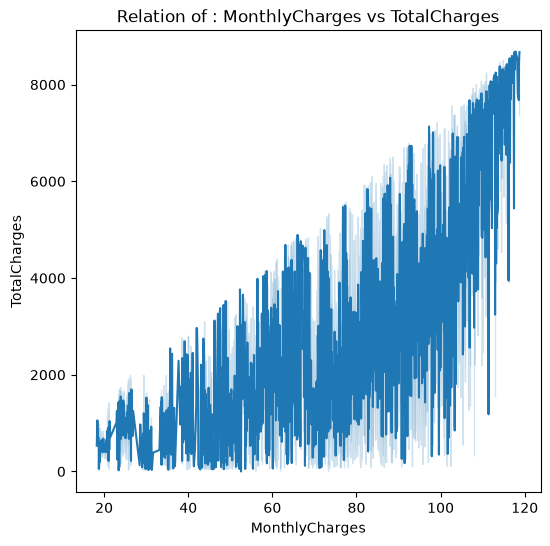

In [79]:
line_plot(df, "MonthlyCharges", "TotalCharges")

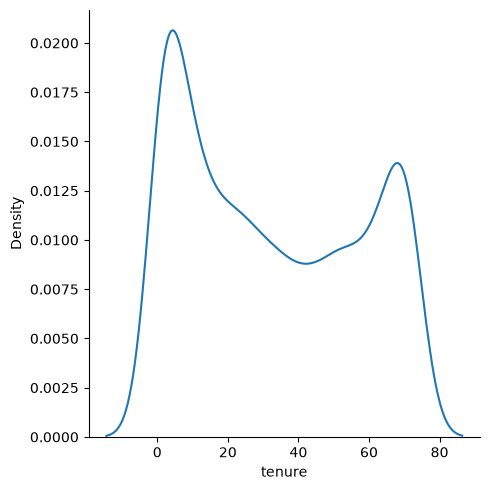

In [80]:
sns.displot(df[df['gender']=='Male']['tenure'],kind='kde')

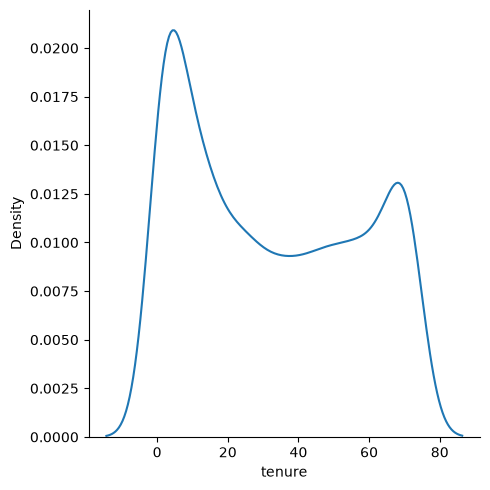

In [81]:
sns.displot(df[df['gender']=='Female']['tenure'],kind='kde')

#### churn vs numerical features

In [91]:
def num_vs_category(df, y_column):
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(df, x="Churn", y=y_column)
    
    plt.title(f"Churn vs {y_column}")
    plt.show()

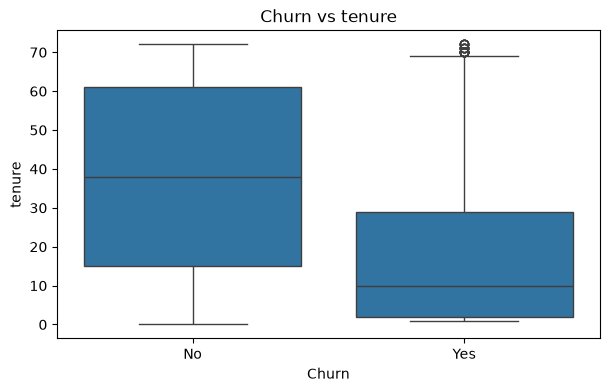

In [92]:
num_vs_category(df, "tenure")

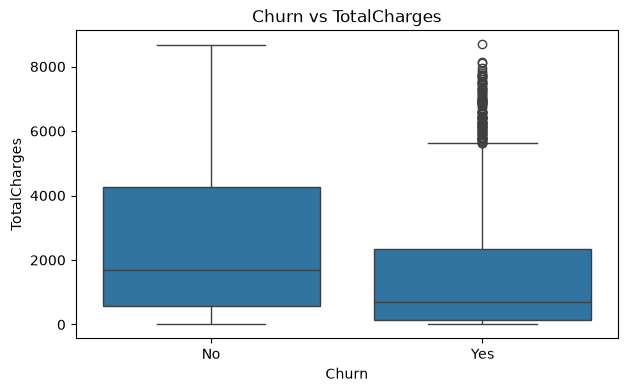

In [93]:
num_vs_category(df, "TotalCharges")

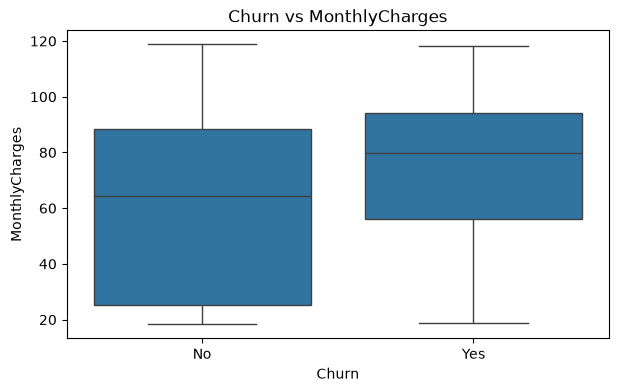

In [94]:
num_vs_category(df, "MonthlyCharges")

#### categorical feature analysis

<Axes: >

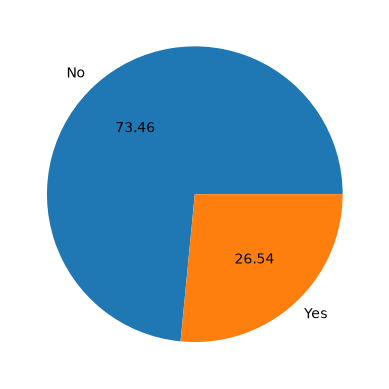

In [36]:
df["Churn"].value_counts().plot(kind="pie",autopct='%.2f')

In [37]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [96]:
cat_col = df.select_dtypes(include="object").columns.tolist()

C:\Users\chira\AppData\Local\Temp\ipykernel_14772\100556017.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include="object").columns.tolist()


In [97]:
print(cat_col)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [39]:
df[['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn']].head(3)

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [98]:
df[cat_col].nunique().sort_values()

gender              2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
Churn               2
MultipleLines       3
InternetService     3
OnlineBackup        3
OnlineSecurity      3
DeviceProtection    3
TechSupport         3
StreamingMovies     3
StreamingTV         3
Contract            3
PaymentMethod       4
dtype: int64

In [40]:
# step-2 Numerical feature
df[['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn']].describe()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


<Axes: xlabel='Churn', ylabel='PaymentMethod'>

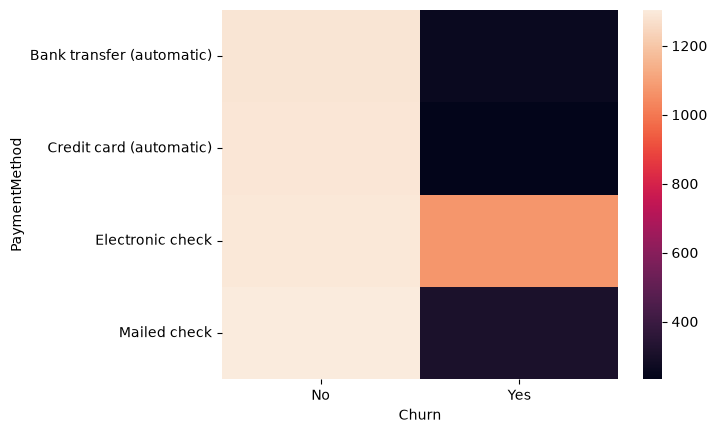

In [41]:
sns.heatmap(pd.crosstab(df['PaymentMethod'],df['Churn']))

In [42]:
pd.crosstab(df['OnlineSecurity'],df['Churn'])

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


In [100]:
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn']:
    if col != "Churn":
        print(pd.crosstab(df[col],df['Churn']))
        print("-"*10)

Churn     No  Yes
gender           
Female  2549  939
Male    2625  930
----------
Churn      No   Yes
Partner            
No       2441  1200
Yes      2733   669
----------
Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326
----------
Churn           No   Yes
PhoneService            
No             512   170
Yes           4662  1699
----------
Churn               No  Yes
MultipleLines              
No                2541  849
No phone service   512  170
Yes               2121  850
----------
Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113
----------
Churn                  No   Yes
OnlineSecurity                 
No                   2037  1461
No internet service  1413   113
Yes                  1724   295
----------
Churn                  No   Yes
OnlineBackup                   
No                   1855  1233
No internet service  1413   113
Yes        

In [101]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


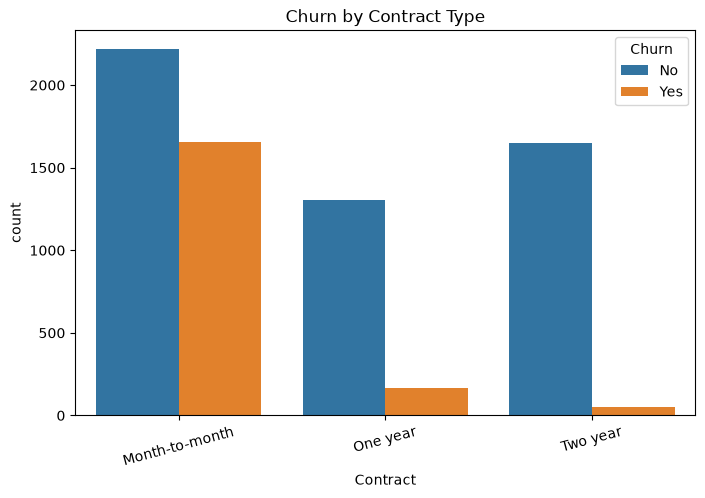

In [102]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

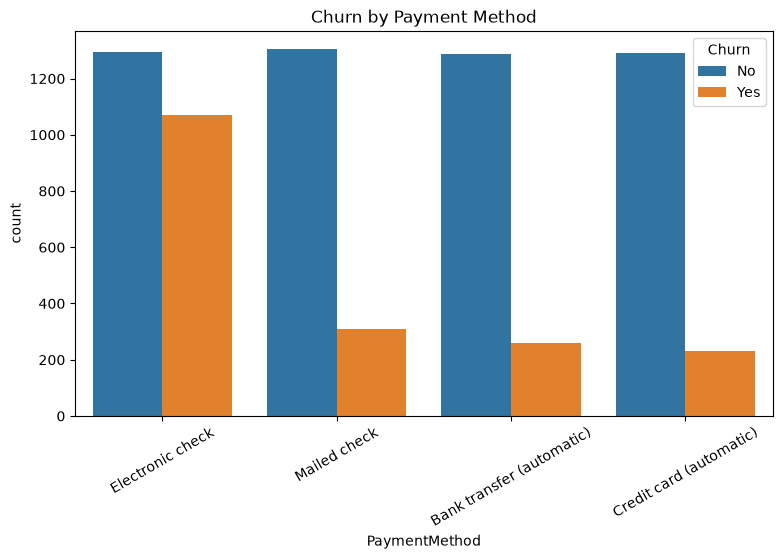

In [103]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)
plt.title("Churn by Payment Method")
plt.xticks(rotation=30)
plt.show()

## churn by InternetService

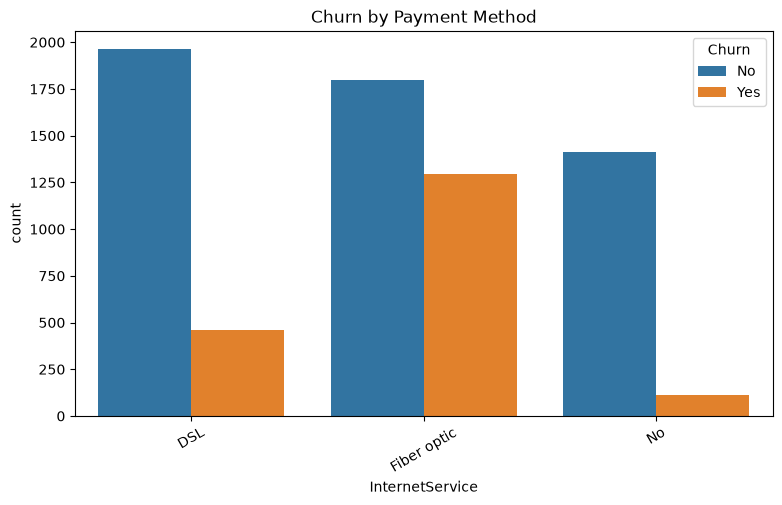

In [104]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)
plt.title("Churn by Payment Method")
plt.xticks(rotation=30)
plt.show()

#### Numerical correlation

In [109]:
num_col = df.select_dtypes(include="number").columns.tolist()

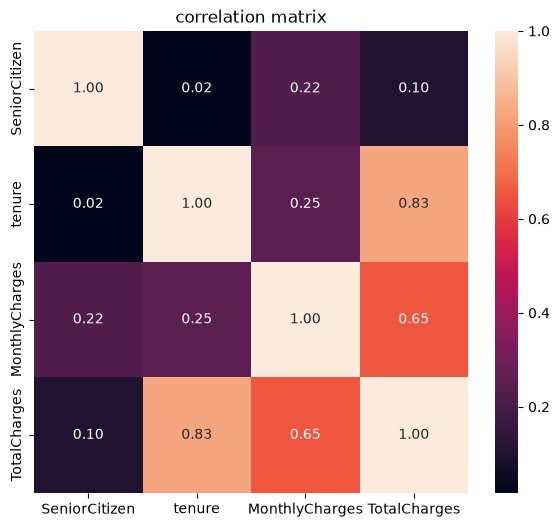

In [113]:
plt.figure(figsize=(7,6))
sns.heatmap(df[num_col].corr(),annot=True,fmt=".2f")
plt.title("correlation matrix")
plt.show()

In [114]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [145]:
import scipy.stats as stats

In [155]:
def churn_kdeplot(df, x_column):
    
    fig,ax = plt.subplots(1, 2, figsize=(12,5))
   
    sns.kdeplot(df[df['Churn']=='Yes'][x_column],color="blue",ax=ax[0])
    ax[0].set_title("chun='Yes'")
   
    sns.kdeplot(df[df['Churn']=='No'][x_column],color="red",ax=ax[1])
    ax[1].set_title("churn='No'")
    
    plt.show()

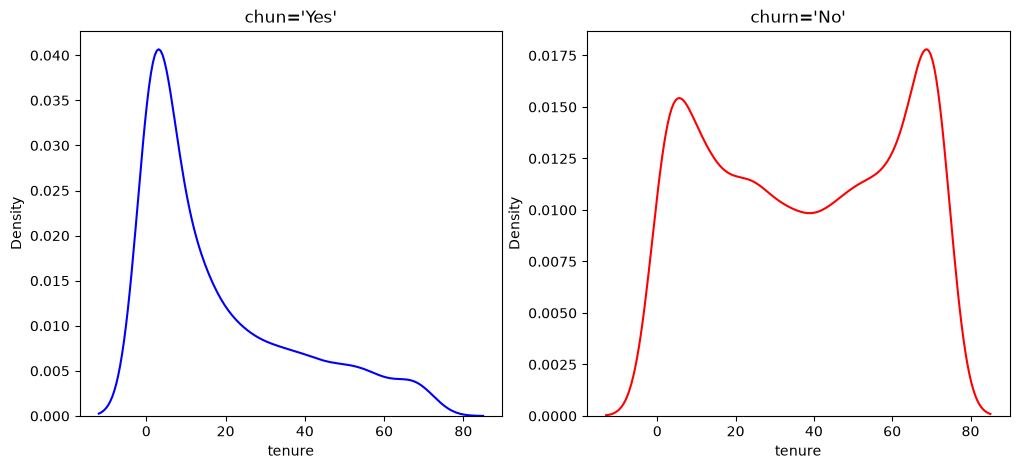

In [156]:
churn_kdeplot(df, "tenure")

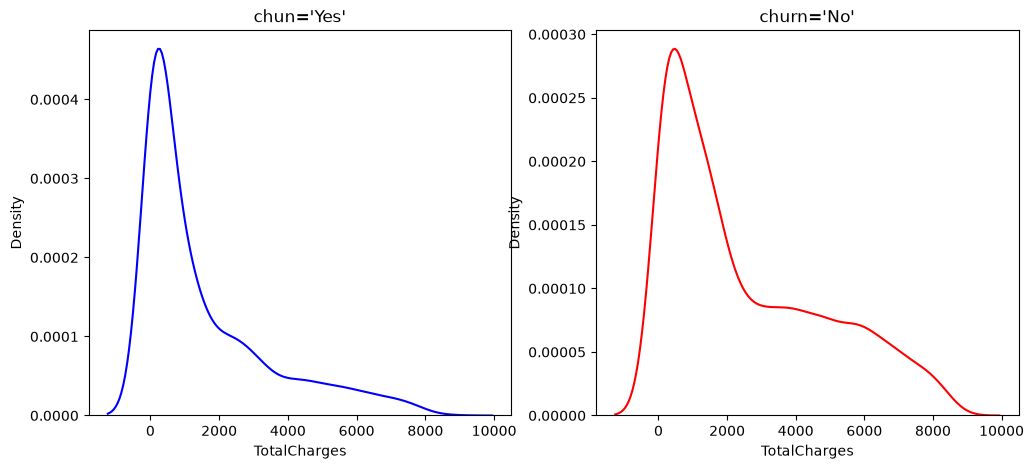

In [157]:
churn_displot(df, "TotalCharges")

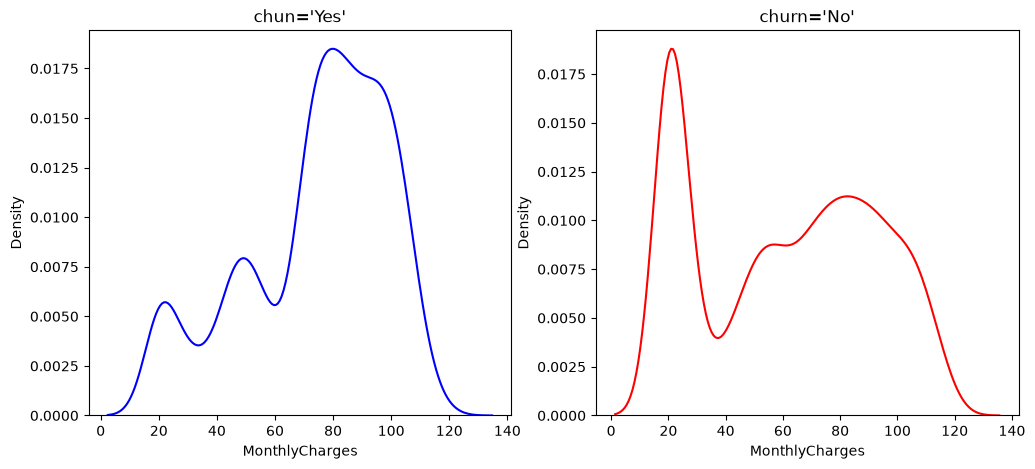

In [158]:
churn_displot(df, "MonthlyCharges")

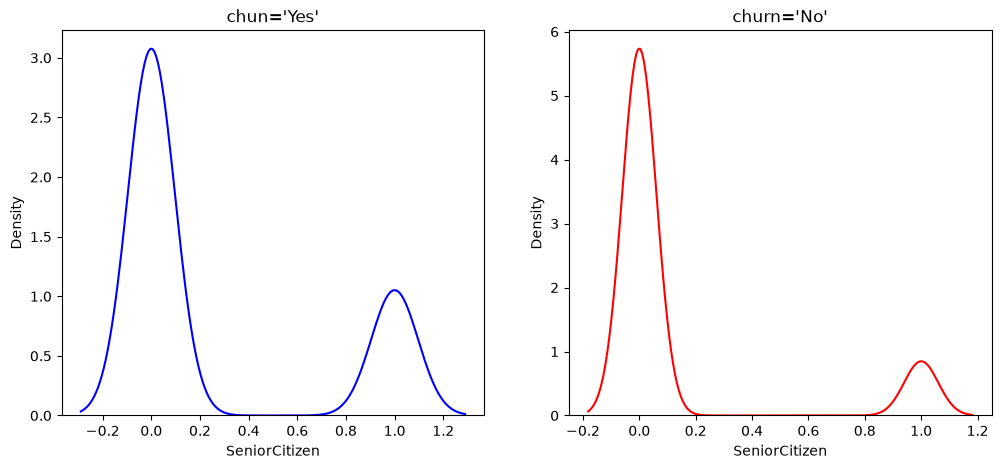

In [161]:
churn_displot(df, "SeniorCitizen")

In [152]:
def churn_QQplot(df, x_column):
    
    fig,ax = plt.figure(figsize=(12,5))

    
    stats.probplot(df[df['Churn']=='Yes'][x_column],dist="norm",plot=plt)
    ax[0].set_title("chun='Yes'")
   
    stats.probplot(df[df['Churn']=='No'][x_column],dist="norm",plot=plt)
    ax[1].set_title("churn='No'")
    
    plt.show()

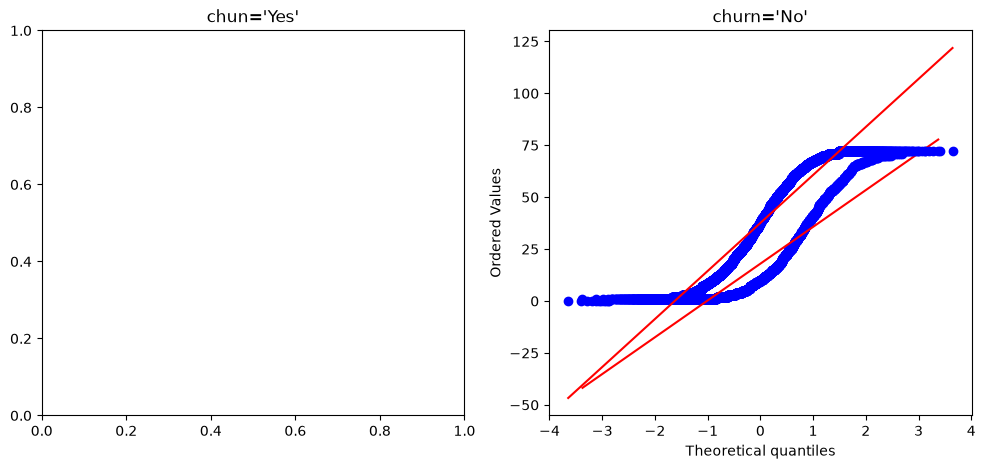

In [153]:
churn_QQplot(df, "tenure")

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [162]:
project_root

WindowsPath('C:/Users/chira/OneDrive/Desktop/customer-churn-predictor')

In [ ]:
from pathlib import Path
processed_path = Path(project_root / "data" / "processed" / "Telco-Churn_cleaned-1.csv")
df.to